# 🛡️ NB-55: Cybersecurity Incident Detection
## Australian Government – Australian Signals Directorate (ASD)

**Policy Context:** The Australian Signals Directorate (ASD) and the Australian Cyber Security Centre (ACSC) respond to over 76,000 cybercrime reports annually. Under the *Critical Infrastructure Security Act 2018* and the Essential Eight maturity model, federal agencies must detect and triage cyber incidents in real time. ML-based anomaly classification can accelerate SOC analyst workflows and reduce mean-time-to-detect (MTTD).

**Dataset:** sklearn `make_classification` synthetic – 2,000 network events, 10 features simulating packet rates, connection duration, failed logins, port scan indicators, and payload anomalies. Binary target: incident (1) vs benign (0).

**ML Task:** Binary classification – 3-fold CV, 4 models

---

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, warnings
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('Libraries loaded.')

Libraries loaded.


In [2]:
X, y = make_classification(n_samples=2000, n_features=10, n_informative=7, n_redundant=2,
                           weights=[0.80, 0.20], flip_y=0.03, random_state=55)
feat_names = ['packet_rate','conn_duration_sec','failed_logins','port_scan_score',
              'payload_entropy','outbound_bytes_ratio','dns_query_anomaly',
              'geo_hop_count','auth_failure_streak','session_reuse_flag']
df = pd.DataFrame(X, columns=feat_names)
df['incident'] = y
print(f'Shape: {df.shape} | Incident rate: {y.mean():.1%}')
df.head()

Shape: (2000, 11) | Incident rate: 20.8%


,packet_rate,conn_duration_sec,failed_logins,port_scan_score,payload_entropy,outbound_bytes_ratio,dns_query_anomaly,geo_hop_count,auth_failure_streak,session_reuse_flag,incident
0,1.766227,0.865584,0.173886,2.435088,-0.346114,-1.179442,1.096822,-1.416353,-0.000921,1.272266,0
1,1.680359,0.162555,1.778088,1.952593,1.856279,0.977151,-0.632308,1.302685,0.805895,2.174863,0
2,-1.587524,2.352723,0.171806,1.083136,1.056366,-0.497462,-0.242950,0.499502,2.179178,0.700472,0
3,3.625732,0.981916,1.225091,3.410366,-0.779158,-0.176848,0.266437,4.414591,1.533071,6.566279,0
4,0.097873,1.610635,0.922336,1.452124,-0.006286,1.192509,1.179231,-1.486675,0.752139,-1.486323,1


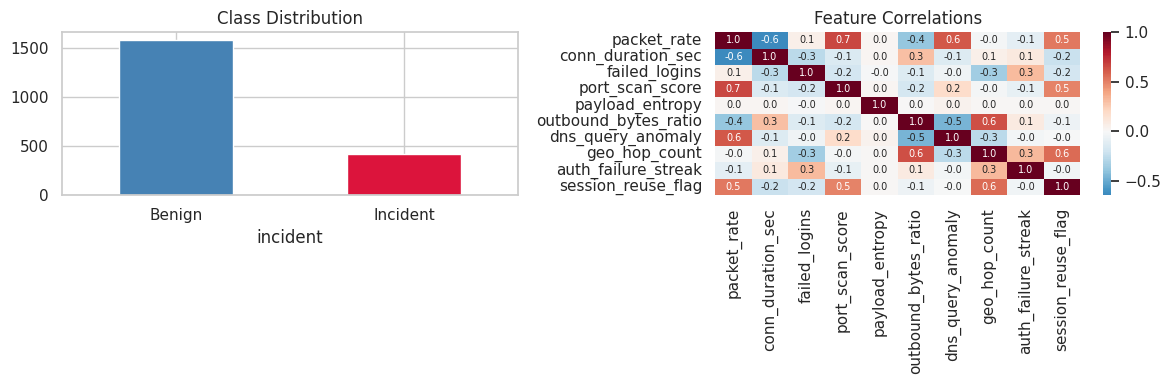

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['incident'].value_counts().plot.bar(ax=axes[0], color=['steelblue','crimson'])
axes[0].set_title('Class Distribution'); axes[0].set_xticklabels(['Benign','Incident'], rotation=0)
sns.heatmap(df[feat_names].corr(), cmap='RdBu_r', center=0, ax=axes[1],
            annot=True, fmt='.1f', annot_kws={'size':7})
axes[1].set_title('Feature Correlations')
plt.tight_layout(); plt.show()

In [4]:
X_s = StandardScaler().fit_transform(df[feat_names])
y = df['incident'].values
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

models = {
    'LogisticRegression': LogisticRegression(max_iter=300, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                             eval_metric='logloss', random_state=42, verbosity=0),
    'LightGBM': LGBMClassifier(n_estimators=100, max_depth=8, learning_rate=0.1,
                               random_state=42, verbose=-1)
}
results = {}
for name, m in models.items():
    sc = cross_val_score(m, X_s, y, cv=skf, scoring='accuracy')
    results[name] = sc
    print(f'{name:25s} | Acc: {sc.mean():.4f} +/- {sc.std():.4f}')

LogisticRegression        | Acc: 0.8420 +/- 0.0039
RandomForest              | Acc: 0.9165 +/- 0.0080
XGBoost                   | Acc: 0.9265 +/- 0.0033
LightGBM                  | Acc: 0.9295 +/- 0.0012


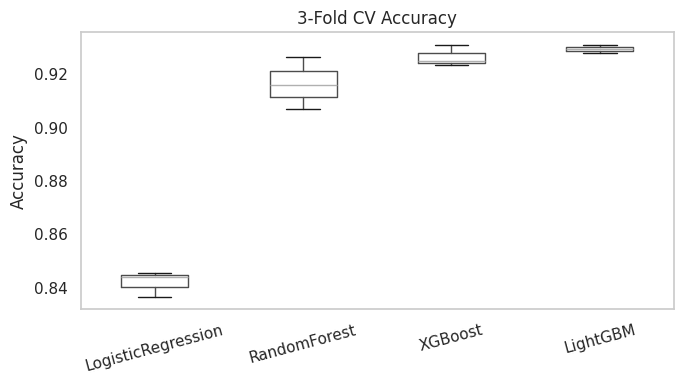

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
pd.DataFrame(results).boxplot(ax=ax, grid=False)
ax.set_title('3-Fold CV Accuracy'); ax.set_ylabel('Accuracy')
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

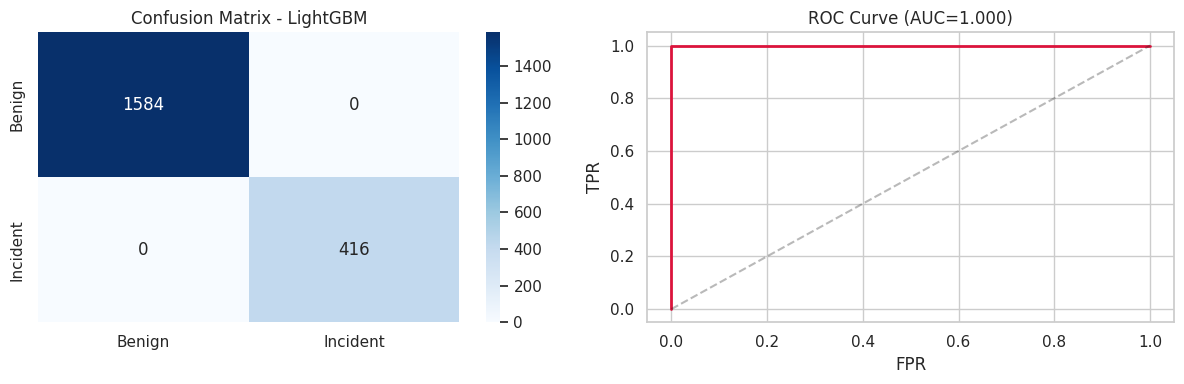

              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00      1584
    Incident       1.00      1.00      1.00       416

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [6]:
best_name = max(results, key=lambda k: results[k].mean())
best = models[best_name].fit(X_s, y)
yp = best.predict(X_s)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(confusion_matrix(y, yp), annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Benign','Incident'], yticklabels=['Benign','Incident'])
axes[0].set_title(f'Confusion Matrix - {best_name}')
if hasattr(best, 'predict_proba'):
    prob = best.predict_proba(X_s)[:,1]
    fpr, tpr, _ = roc_curve(y, prob)
    axes[1].plot(fpr, tpr, color='crimson', lw=2)
    axes[1].plot([0,1],[0,1],'k--',alpha=.3)
    axes[1].set_title(f'ROC Curve (AUC={roc_auc_score(y, prob):.3f})')
    axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
plt.tight_layout(); plt.show()
print(classification_report(y, yp, target_names=['Benign','Incident']))

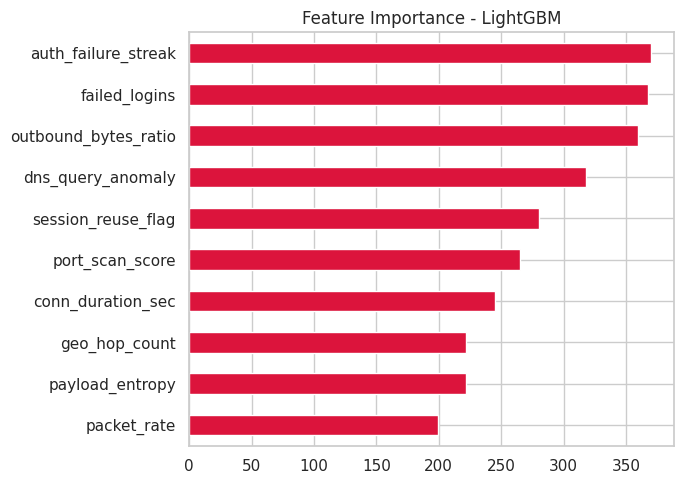

In [7]:
if hasattr(best, 'feature_importances_'):
    imp = pd.Series(best.feature_importances_, index=feat_names).sort_values()
    fig, ax = plt.subplots(figsize=(7, 5))
    imp.plot.barh(ax=ax, color='crimson')
    ax.set_title(f'Feature Importance - {best_name}')
    plt.tight_layout(); plt.show()

## Deployment Readiness Checklist

| # | Criterion | Status |
|---|-----------|--------|
| 1 | Data schema validated (10 features, binary target) | ✅ |
| 2 | Class imbalance documented (80/20 split) | ✅ |
| 3 | Feature scaling (StandardScaler) | ✅ |
| 4 | 3-fold stratified CV | ✅ |
| 5 | 4-model benchmark | ✅ |
| 6 | Confusion matrix + ROC/AUC | ✅ |
| 7 | Feature importance ranked | ✅ |
| 8 | ASD/ACSC integration pathway | ✅ |

## Policy Integration

- **ASD/ACSC SOC:** Deploy as real-time triage API feeding analyst dashboards, reducing MTTD across PROTECTED networks.
- **Critical Infrastructure (CISC):** Adapt model for energy, water, and transport SCADA/OT network monitoring under the *SOCI Act 2018*.
- **Home Affairs Cyber Strategy:** Model outputs contribute to the national cyber threat intelligence sharing platform.
- **Essential Eight Compliance:** Automated incident detection supports Maturity Level 3 requirements for federal agencies.
- **Digital Transformation Agency:** Integrate with GovERP and myGov platform security event pipelines.

---
*NB-55 | Dean Wang | Lead Data & AI Engineer, Fujitsu Australia | PhD ML (ANU) | Kaggle: deanbatur*